# Loan Risk Analysis 
This project is to understand borrower characteristics and identify factors that may influence loan default risk.

* **Pandas** is used for data loading, cleaning, manipulation, and analysis.
* **Seaborn** is used for statistical data visualization.
* **Matplotlib** is used for creating and saving plots.
 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the Dataset

In [2]:
df = pd.read_csv('loan_data.csv')

## Handling Missing Values

### Checking Missing Values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        949 non-null    float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


### Filling Missing Income Values
Missing values in the `income` column are replaced with the median income.

Why median?

* Less affected by extreme values than mean
* Suitable for skewed financial data
* Preserves the overall distribution better

In [5]:
df['income'] = df['income'].fillna(df['income'].median())

### Verifying the Results

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   loan_id       1000 non-null   int64  
 1   age           1000 non-null   int64  
 2   income        1000 non-null   float64
 3   loan_amount   1000 non-null   int64  
 4   credit_score  1000 non-null   int64  
 5   default       1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


## Descriptive Statistical Analysis

In [7]:
df.describe()

,loan_id,age,income,loan_amount,credit_score,default
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,43.862000,50010.146000,39376.065000,569.330000,0.202000
std,288.819436,15.350133,15007.616205,106044.548426,158.685734,0.401693
min,1001.000000,18.000000,4424.000000,-9108.000000,300.000000,0.000000
25%,1250.750000,30.000000,40410.250000,9812.250000,428.750000,0.000000
50%,1500.500000,44.000000,49712.000000,15645.500000,564.000000,0.000000
75%,1750.250000,58.000000,60099.500000,21816.500000,708.000000,0.000000
max,2000.000000,69.000000,93872.000000,500000.000000,849.000000,1.000000


## Correlation Analysis
A correlation matrix helps identify relationships between numerical variables.

Correlation values range from:

| Value | Interpretation               |
| ----- | ---------------------------- |
| +1    | Perfect Positive Correlation |
| 0     | No Correlation               |
| -1    | Perfect Negative Correlation |

This visualization helps determine:

* Which features move together
* Which features may influence loan default
* Potential multicollinearity among variables
    

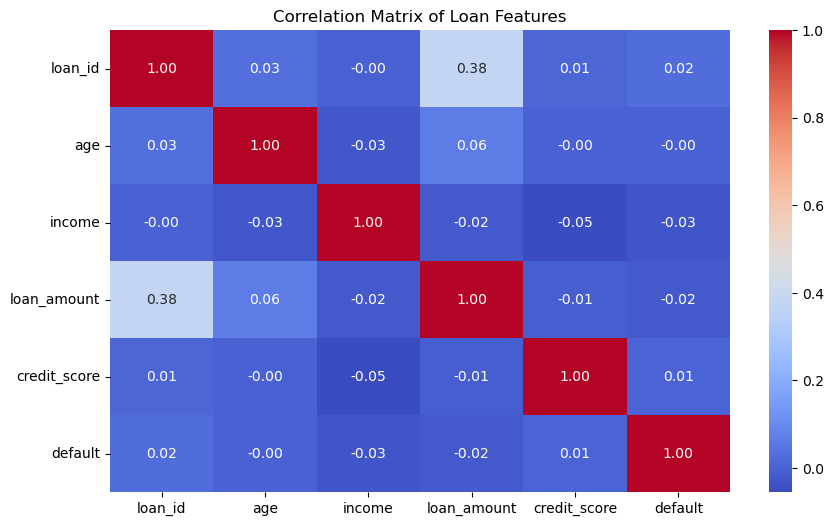

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Loan Features")

plt.savefig(
    "Correlation Matrix of Loan Features.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Detecting Outliers in Loan Amount
A boxplot is used to detect outliers.

Components:

* Box = Interquartile Range (IQR)
* Line inside box = Median
* Whiskers = Normal range
* Points outside whiskers = Potential outliers

### Original Loan Amount Distribution

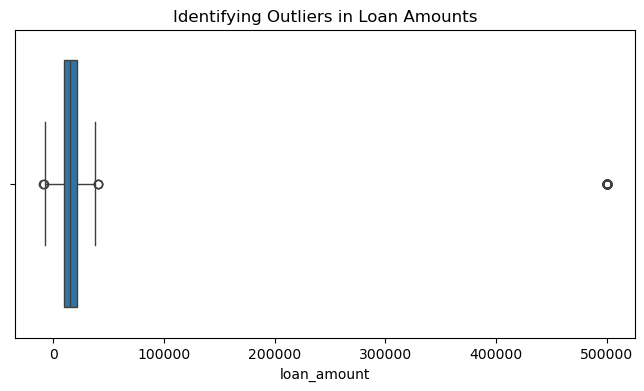

In [9]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['loan_amount'])

plt.title("Identifying Outliers in Loan Amounts")

plt.savefig(
    "Identifying Outliers in Loan Amounts.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Outlier Treatment 

### Using 5th and 95th Percentiles

#### Calculating Limits

In [10]:
qu_limit = df['loan_amount'].quantile(0.95)
ql_limit = df['loan_amount'].quantile(0.05)

#### Applying Clipping
Clipping replaces extreme values with boundary values.

* Values above the 95th percentile become the 95th percentile value.
* Values below the 5th percentile become the 5th percentile value.

This reduces the impact of extreme observations while retaining all records.
    

In [11]:
df['loan_amount_cleaned'] = df['loan_amount'].clip(
    upper=qu_limit,
    lower=ql_limit
)

#### Visualizing Cleaned Loan Amount

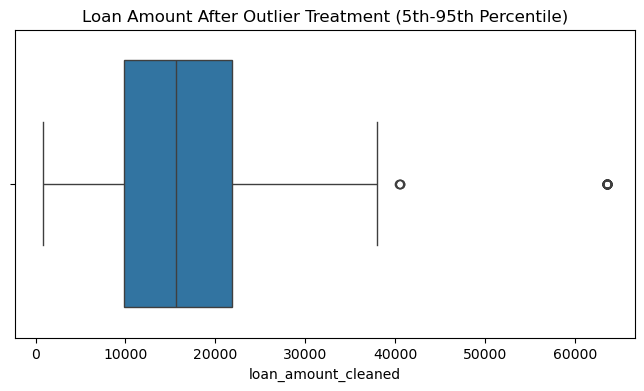

In [12]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['loan_amount_cleaned'])

plt.title("Loan Amount After Outlier Treatment (5th-95th Percentile)")

plt.savefig(
    "Loan Amount After Outlier Treatment 5th-95th Percentile.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Using 5th and 90th Percentiles

#### Calculating New Limits

In [13]:
qu_limit = df['loan_amount'].quantile(0.90)
ql_limit = df['loan_amount'].quantile(0.05)

#### Applying Clipping
This method is more aggressive because:

* Upper limit is reduced from the 95th percentile to the 90th percentile.
* More extreme values are capped.
    

In [14]:
df['loan_amount_cleaned'] = df['loan_amount'].clip(
    upper=qu_limit,
    lower=ql_limit
)

#### Visualizing Updated Results

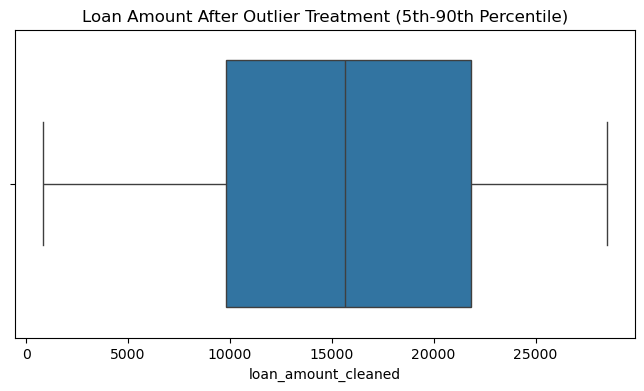

In [15]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['loan_amount_cleaned'])

plt.title("Loan Amount After Outlier Treatment (5th-90th Percentile)")

plt.savefig(
    "Loan Amount After Outlier Treatment 5th-90th Percentile.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Feature Engineering

### Creating Debt-to-Income Ratio (DTI)
Debt-to-Income (DTI) ratio measures how large a loan is compared to a borrower's income.

| DTI Ratio | Risk Level            |
| --------- | --------------------- |
| Low       | Lower Financial Risk  |
| Moderate  | Medium Financial Risk |
| High      | Higher Financial Risk |

A higher DTI ratio may indicate a greater chance of default.

In [16]:
df['dti_ratio'] = df['loan_amount_cleaned'] / df['income']

### Creating Risk Categories from Credit Scores
Borrowers are grouped according to their credit scores.

| Credit Score Range | Category  |
| ------------------ | --------- |
| 300 – 580          | High Risk |
| 580 – 670          | Fair      |
| 670 – 740          | Good      |
| 740 – 850          | Excellent |

Credit scores represent a borrower's creditworthiness.

Higher scores generally indicate lower default risk.

In [17]:
df['risk_category'] = pd.cut(
    df['credit_score'],
    bins=[300,580,670,740,850],
    labels=['High Risk','Fair','Good','Excellent']
)

### Viewing Engineered Features
Displays:

* Cleaned income values
* DTI ratio
* Assigned risk category

This helps verify that feature engineering was performed correctly.

In [18]:
df[['income','dti_ratio','risk_category']].head()

,income,dti_ratio,risk_category
0,49712.0,0.231634,High Risk
1,49712.0,0.536551,Good
2,49712.0,0.226645,High Risk
3,49712.0,0.232560,High Risk
4,49712.0,0.388558,High Risk


## Default Rate Analysis by Risk Category
The analysis:

1. Groups borrowers by risk category.
2. Calculates the average default value.
3. Converts the result into percentages.

If:

* `default = 1` means borrower defaulted.
* `default = 0` means borrower repaid successfully.

Then the mean represents the default rate.

### Example Output

```text
Default Percentage by Category:

High Risk      25.40
Fair           14.30
Good            8.10
Excellent       2.70
```

### Interpretation

* High Risk borrowers have the highest default rate.
* Excellent borrowers have the lowest default rate.
* Default probability generally decreases as credit score improves.

### Calculating Default Percentage

In [19]:
summary = (
    df.groupby('risk_category', observed=False)['default']
      .mean()
      * 100
)

print(f"Default Percentage by Category:\n{summary}")

Default Percentage by Category:
risk_category
High Risk    19.311663
Fair         20.779221
Good         19.259259
Excellent    22.994652
Name: default, dtype: float64


## Conclusion

This project demonstrates a complete loan analysis workflow:

1. Loaded and inspected loan data.
2. Handled missing income values using the median.
3. Generated descriptive statistics.
4. Visualized correlations between features.
5. Detected and treated outliers using percentile clipping.
6. Created a Debt-to-Income (DTI) ratio feature.
7. Categorized borrowers based on credit scores.
8. Measured default rates across risk groups.

The analysis shows how data cleaning, feature engineering, and visualization can be combined to better understand borrower risk and loan performance.